# MovieLens Rating Prediction Workshop Notebook

This example is derived from the official PyTorch Geometric [Tutorial](https://pytorch-geometric.readthedocs.io/en/latest/get_started/colabs.html).


## Setup


In [86]:
import torch

print("torch:", torch.__version__)
cuda_available = torch.cuda.is_available()
print("cuda available:", cuda_available)
if cuda_available:
    print("torch cuda device count:", torch.cuda.device_count())
    print(
        "torch cuda device name:",
        torch.cuda.get_device_name(torch.cuda.current_device()),
    )
print("torch cuda:", torch.version.cuda)

torch: 2.8.0+cu129
cuda available: True
torch cuda device count: 1
torch cuda device name: NVIDIA GeForce RTX 3070
torch cuda: 12.9


## Link Regression on the MovieLens Dataset

This notebook shows how to load a set of `*.csv` files into a `torch_geometric.data.HeteroData` object and how to train a [heterogeneous graph model](https://pytorch-geometric.readthedocs.io/en/latest/notes/heterogeneous.html#hgtutorial).

We are going to use the [Movielens dataset](https://grouplens.org/datasets/movielens/), which is collected by the GroupLens Research group. The toy dataset describes movies, users, and their ratings. We are going to predict the rating of a user for a movie.


## Data Ingestion


In [87]:
from torch_geometric.data import download_url, extract_zip
import pandas as pd

folder_path = "../../model/data"
dataset_name = "ml-latest-small"

url = f"https://files.grouplens.org/datasets/movielens/{dataset_name}.zip"
extract_zip(download_url(url, folder_path), folder_path)

movies_path = f"{folder_path}/{dataset_name}/movies.csv"
ratings_path = f"{folder_path}/{dataset_name}/ratings.csv"

Using existing file ml-latest-small.zip
Extracting ../../model/data\ml-latest-small.zip


In [88]:
# Load the entire ratings dataframe into memory:
ratings_df = pd.read_csv(ratings_path)[["userId", "movieId", "rating"]]

# Load the entire movie dataframe into memory:
movies_df = pd.read_csv(movies_path, index_col="movieId")

print("movies.csv:")
print("===========")
print(movies_df[["genres", "title"]].head())
print(f"Number of movies: {len(movies_df)}")
print()
print("ratings.csv:")
print("============")
print(ratings_df[["userId", "movieId", "rating"]].head())
print(f"Number of ratings: {len(ratings_df)}")
print()

movies.csv:
                                              genres  \
movieId                                                
1        Adventure|Animation|Children|Comedy|Fantasy   
2                         Adventure|Children|Fantasy   
3                                     Comedy|Romance   
4                               Comedy|Drama|Romance   
5                                             Comedy   

                                      title  
movieId                                      
1                          Toy Story (1995)  
2                            Jumanji (1995)  
3                   Grumpier Old Men (1995)  
4                  Waiting to Exhale (1995)  
5        Father of the Bride Part II (1995)  
Number of movies: 9742

ratings.csv:
   userId  movieId  rating
0       1        1     4.0
1       1        3     4.0
2       1        6     4.0
3       1       47     5.0
4       1       50     5.0
Number of ratings: 100836



Additionally, let's add our ratings to the dataset to get predictions for movies we haven't seen yet.

There are two ways to add ratings:

1. **Add ratings manually**
2. **Upload IMDB ratings**


### Add your ratings manually

We recommend adding at least 10 ratings. Let's first check out the most rated movies. Additional movies in the table are: _Avatar_, _The Dark Knight_, _Pretty Women_,
_Titanic_, _The Lion King_, _Jurassic Park_, _The Matrix_, _The Lord of the Rings_ and _The Avengers_. Please note that the article in the movie title is often at the end of the title.


In [ ]:
# Specify your userId
our_user_id = ratings_df["userId"].max() + 1

print("Most rated movies:")
print("==================")
most_rated_movies = ratings_df["movieId"].value_counts().head(10)
most_rated_movies_with_counts = movies_df.loc[most_rated_movies.index, ["title"]].copy()
most_rated_movies_with_counts["num_ratings"] = most_rated_movies.values
print(most_rated_movies_with_counts)
# Initialize your rating list
personal_ratings = []

Most rated movies:
                                             title  num_ratings
movieId                                                        
356                            Forrest Gump (1994)          329
318               Shawshank Redemption, The (1994)          317
296                            Pulp Fiction (1994)          307
593               Silence of the Lambs, The (1991)          279
2571                            Matrix, The (1999)          278
260      Star Wars: Episode IV - A New Hope (1977)          251
480                           Jurassic Park (1993)          238
110                              Braveheart (1995)          237
589              Terminator 2: Judgment Day (1991)          224
527                        Schindler's List (1993)          220


In [90]:
# Add ratings to the dataframe:
personal_ratings.append({"movieId": 356, "rating": 5.0, "userId": our_user_id})
personal_ratings.append({"movieId": 318, "rating": 4.0, "userId": our_user_id})
personal_ratings.append({"movieId": 296, "rating": 5.0, "userId": our_user_id})
personal_ratings.append({"movieId": 593, "rating": 3.0, "userId": our_user_id})
personal_ratings.append({"movieId": 2571, "rating": 5.0, "userId": our_user_id})
personal_ratings.append({"movieId": 260, "rating": 3.0, "userId": our_user_id})
personal_ratings.append({"movieId": 480, "rating": 3.0, "userId": our_user_id})
personal_ratings.append({"movieId": 110, "rating": 1.0, "userId": our_user_id})
personal_ratings.append({"movieId": 589, "rating": 4.0, "userId": our_user_id})
personal_ratings.append({"movieId": 527, "rating": 3.0, "userId": our_user_id})

The next cell: either add personal ratings to training data or only use them for inference later


In [91]:
# ratings_df = pd.concat([ratings_df, pd.DataFrame.from_records(ratings)])

## Data Preprocessing

We are going to use the genre as well as the title of the movie as node features. For the `title` features, we are going to use a pre-trained [sentence transformer](https://www.sbert.net/) model to encode the title into a vector.
For the `genre` features, we are going to use a one-hot encoding.


In [92]:
import numpy as np
import torch
from sentence_transformers import SentenceTransformer

# One-hot encode the genres:
genres = movies_df["genres"].str.get_dummies("|").values
genres = torch.from_numpy(genres).to(torch.float)

# Load the pre-trained sentence transformer model and encode the movie titles:
model = SentenceTransformer("all-MiniLM-L6-v2")
with torch.no_grad():
    titles = model.encode(
        movies_df["title"].tolist(), convert_to_tensor=True, show_progress_bar=True
    )
    titles = titles.cpu()

# Concatenate the genres and title features:
movie_features = torch.cat([genres, titles], dim=-1)

# We don't have user features: use a simple constant feature for each user to allow the future inference with new users:
num_users = len(ratings_df["userId"].unique())
user_features = torch.ones((num_users, 1), dtype=torch.float)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/305 [00:00<?, ?it/s]

The `ratings.csv` file contains the ratings of users for movies. From this
file we are extracting the `userId`. We create a mapping from the `userId`
to a unique consecutive value in the range `[0, num_users]`. This is needed as we want our final data representation to be as compact as possible, _e.g._, the representation of a user in the first row should be accessible via `x[0]`.
The same we do for the `movieId`.
Afterwards, we obtain the final `edge_index` representation of shape `[2, num_ratings]` from `ratings.csv` by merging mapped user and movie indices with the raw indices given by the original data frame.


In [93]:
# Create a mapping from the userId to a unique consecutive value in the range [0, num_users]:
unique_user_id = ratings_df["userId"].unique()
unique_user_id = pd.DataFrame(
    data={"userId": unique_user_id, "mappedUserId": pd.RangeIndex(len(unique_user_id))}
)
print("Mapping of user IDs to consecutive values:")
print("==========================================")
print(unique_user_id.head())
print()

# Create a mapping from the movieId to a unique consecutive value in the range [0, num_movies]:
unique_movie_id = ratings_df["movieId"].unique()
unique_movie_id = pd.DataFrame(
    data={
        "movieId": unique_movie_id,
        "mappedMovieId": pd.RangeIndex(len(unique_movie_id)),
    }
)
print("Mapping of movie IDs to consecutive values:")
print("===========================================")
print(unique_movie_id.head())
print()

# Merge the mappings with the original data frame:
ratings_df = ratings_df.merge(unique_user_id, on="userId")
ratings_df = ratings_df.merge(unique_movie_id, on="movieId")

# With this, we are ready to create the edge_index representation in COO format
# following the PyTorch Geometric semantics:
edge_index = torch.stack(
    [
        torch.tensor(ratings_df["mappedUserId"].values),
        torch.tensor(ratings_df["mappedMovieId"].values),
    ],
    dim=0,
)

assert edge_index.shape == (2, len(ratings_df))

print("Final edge indices pointing from users to movies:")
print("================================================")
print(edge_index[:, :10])

Mapping of user IDs to consecutive values:
   userId  mappedUserId
0       1             0
1       2             1
2       3             2
3       4             3
4       5             4

Mapping of movie IDs to consecutive values:
   movieId  mappedMovieId
0        1              0
1        3              1
2        6              2
3       47              3
4       50              4

Final edge indices pointing from users to movies:
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]])


## Heterogeneous Graph Construction

With this we are ready to initialize our heterogeneous graph data object and pass the
necessary information to it.

We also take care of adding reverse edges to the `HeteroData` object. This allows our GNN
model to use both directions of the edges for the message passing.


In [94]:
import torch_geometric.transforms as T
from torch_geometric.data import HeteroData

# Create the heterogeneous graph data object:
data = HeteroData()

# Add the user nodes:
data["user"].x = user_features  # [num_users, num_features_users]

# Add the movie nodes:
data["movie"].x = movie_features  # [num_movies, num_features_movies]

# Add the rating edges:
data["user", "rates", "movie"].edge_index = edge_index  # [2, num_ratings]

# Add the rating labels:
rating = torch.from_numpy(ratings_df["rating"].values).to(torch.float)
data["user", "rates", "movie"].edge_label = rating  # [num_ratings]
data["user", "rates", "movie"].edge_attr = rating.view(-1, 1)

# We also need to make sure to add the reverse edges from movies to users
# in order to let a GNN be able to pass messages in both directions.
# We can leverage the `T.ToUndirected()` transform for this from PyG:
data = T.ToUndirected()(data)

# With the above transformation we also got reversed labels for the edges.
# We are going to remove them:
del data["movie", "rev_rates", "user"].edge_label

assert data["user"].num_nodes == len(unique_user_id)
assert data["user", "rates", "movie"].num_edges == len(ratings_df)
assert (
    data["movie"].num_features == 404
)  # 20 from genres and 384 from the title embedding

data

HeteroData(
  user={ x=[610, 1] },
  movie={ x=[9742, 404] },
  (user, rates, movie)={
    edge_index=[2, 100836],
    edge_label=[100836],
    edge_attr=[100836, 1],
  },
  (movie, rev_rates, user)={
    edge_index=[2, 100836],
    edge_attr=[100836, 1],
  }
)

In [95]:
data.edge_types

[('user', 'rates', 'movie'), ('movie', 'rev_rates', 'user')]

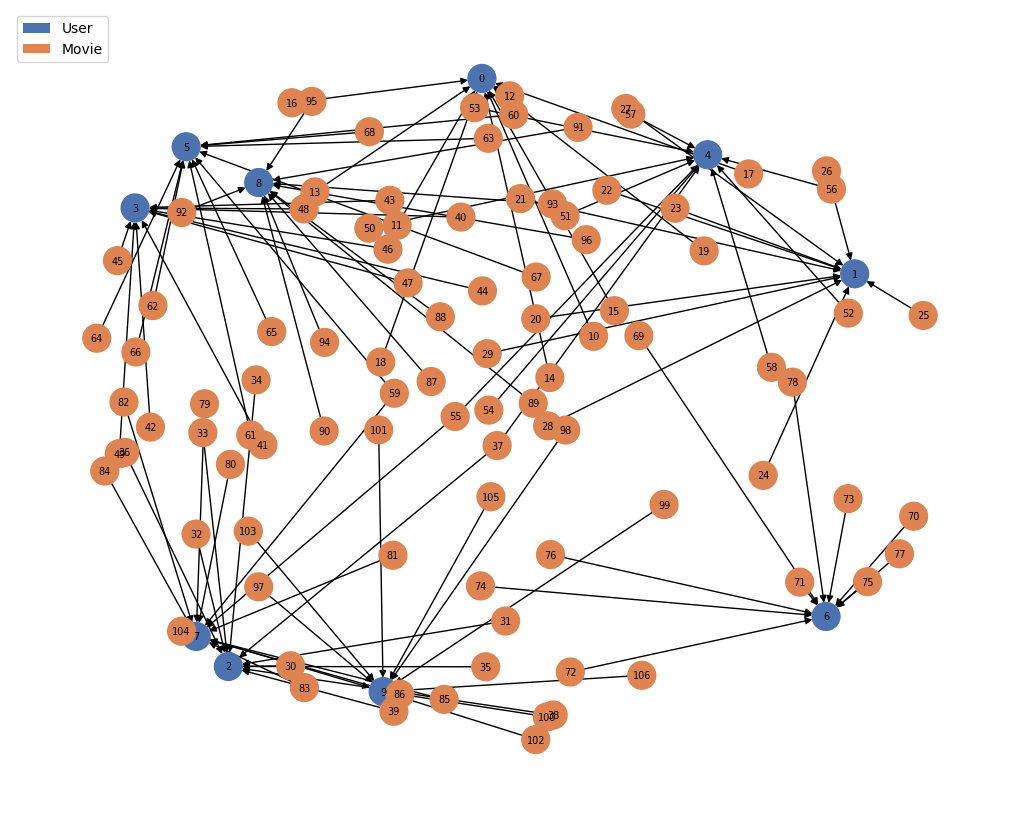

In [ ]:
from torch_geometric.loader import NeighborLoader
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx
from matplotlib.patches import Patch

loader = NeighborLoader(
    data,
    num_neighbors={key: [10] for key in data.edge_types},
    input_nodes=("user", torch.arange(10)),  # sample around first 10 users
    batch_size=10,
)

batch = next(iter(loader))

G = to_networkx(batch)

num_user_nodes = batch["user"].num_nodes
num_movie_nodes = batch["movie"].num_nodes
node_colors = ["#4C72B0"] * num_user_nodes + ["#DD8452"] * num_movie_nodes

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42, k=0.5)
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    node_size=400,
    font_size=7,
)


legend_elements = [
    Patch(facecolor="#4C72B0", label="User"),
    Patch(facecolor="#DD8452", label="Movie"),
]
plt.legend(handles=legend_elements, loc="upper left")
plt.show()

## Dataset Splitting

We can now split our data into a training, validation and test set. We are going to use
the `T.RandomLinkSplit` transform from PyG to do this. This transform will randomly
split the links with their label/rating into training, validation and test set.
We are going to use 80% of the edges for training, 10% for validation and 10% for testing.


In [97]:
train_data, val_data, test_data = T.RandomLinkSplit(
    num_val=0.1,
    num_test=0.1,
    neg_sampling_ratio=0.0,
    edge_types=[("user", "rates", "movie")],
    rev_edge_types=[("movie", "rev_rates", "user")],
    disjoint_train_ratio=0.3,  # this means that 30% of the edges in the training set will be removed from the graph structure and only used for training the link predictor.
    # This allows us to evaluate the model's ability to generalize to unseen edges during validation and testing.
)(data)
train_data, val_data

(HeteroData(
   user={ x=[610, 1] },
   movie={ x=[9742, 404] },
   (user, rates, movie)={
     edge_index=[2, 56469],
     edge_attr=[56469, 1],
     edge_label=[24201],
     edge_label_index=[2, 24201],
   },
   (movie, rev_rates, user)={
     edge_index=[2, 56469],
     edge_attr=[56469, 1],
   }
 ),
 HeteroData(
   user={ x=[610, 1] },
   movie={ x=[9742, 404] },
   (user, rates, movie)={
     edge_index=[2, 80670],
     edge_attr=[80670, 1],
     edge_label=[10083],
     edge_label_index=[2, 10083],
   },
   (movie, rev_rates, user)={
     edge_index=[2, 80670],
     edge_attr=[80670, 1],
   }
 ))

## Graph Neural Network

We are now ready to define our GNN model. We are going to use a simple GNN model with
two message passing layers for the encoding of the user and movie nodes.
Additionally, we are going to use a decoder to predict the rating for the encoded
user-movie combination.


In [ ]:
from torch_geometric.nn import to_hetero, TransformerConv


class GNNEncoder(torch.nn.Module):
    def __init__(self, hidden_channels, out_channels):
        super().__init__()
        # self.conv1 = SAGEConv((-1, -1), hidden_channels)
        # self.conv2 = SAGEConv((-1, -1), out_channels)

        # use edge-feature aware layers:
        self.conv1 = TransformerConv(
            # the line below allows PyG to initialize the layer once it sees actual input feature sizes.
            (-1, -1),
            hidden_channels,
            heads=1,
            concat=False,
            edge_dim=1,
        )

        self.conv2 = TransformerConv(
            (-1, -1),
            out_channels,
            heads=1,
            concat=False,
            edge_dim=1,
        )

    # x = dict of node features for "user" and "movie" node types
    #   shape [num_nodes, num_node_features] <-- num_node_features can be different for users and movies
    # edge_index = dict of graph connectivity for each edge type
    #   shape [2, num_edges]
    # edge_attr = dict of edge features for each edge type.
    #   shape [num_edges, num_edge_features]
    def forward(self, x, edge_index, edge_attr):
        x = self.conv1(x, edge_index, edge_attr).relu()
        x = self.conv2(x, edge_index, edge_attr)
        return x


class EdgeDecoder(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        self.lin1 = torch.nn.Linear(2 * hidden_channels, hidden_channels)
        self.lin2 = torch.nn.Linear(hidden_channels, 1)

    # z_dict = dict of node embeddings for "user" and "movie" node types
    #   shape [num_nodes, hidden_channels]
    # edge_label_index = edge indices for which we want to predict the edge labels
    #   shape [2, num_edges_to_predict]
    def forward(self, z_dict, edge_label_index):
        row, col = edge_label_index
        z = torch.cat([z_dict["user"][row], z_dict["movie"][col]], dim=-1)

        z = self.lin1(z).relu()
        z = self.lin2(z)
        # reshape the output to 1D tensor of shape [num_edges_to_predict]
        return z.view(-1)


class Model(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        self.encoder = GNNEncoder(hidden_channels, hidden_channels)
        self.encoder = to_hetero(self.encoder, data.metadata(), aggr="sum")
        self.decoder = EdgeDecoder(hidden_channels)

    def forward(self, x_dict, edge_index_dict, edge_attr_dict, edge_label_index):
        # GNN encoder outputs
        z_dict = self.encoder(x_dict, edge_index_dict, edge_attr_dict)
        # GNN encoder's variable output only changes the batch size dimension for the decoder
        return self.decoder(z_dict, edge_label_index)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
hidden_channels = 64

model = Model(hidden_channels=hidden_channels).to(device)

print(model)

Model(
  (encoder): GraphModule(
    (conv1): ModuleDict(
      (user__rates__movie): TransformerConv((-1, -1), 64, heads=1)
      (movie__rev_rates__user): TransformerConv((-1, -1), 64, heads=1)
    )
    (conv2): ModuleDict(
      (user__rates__movie): TransformerConv((-1, -1), 64, heads=1)
      (movie__rev_rates__user): TransformerConv((-1, -1), 64, heads=1)
    )
  )
  (decoder): EdgeDecoder(
    (lin1): Linear(in_features=128, out_features=64, bias=True)
    (lin2): Linear(in_features=64, out_features=1, bias=True)
  )
)


## Training a Heterogeneous GNN

Training our GNN is then similar to training any PyTorch model.
We move the model to the desired device, and initialize an optimizer that takes care of adjusting model parameters via stochastic gradient descent.

The training loop applies the forward computation of the model, computes the loss from ground-truth labels and obtained predictions, and adjusts model parameters via back-propagation and stochastic gradient descent.


In [99]:
from datetime import datetime
from pathlib import Path
import os

from dotenv import load_dotenv
import wandb

load_dotenv("../.env")

config = {
    "hidden_channels": hidden_channels,
    "lr": 0.003,
    "weight_decay": 0.0001,
    "epochs": 300,
    "use_wandb": True,
    "artifact_name": "movie-rec-link-regression-weights",
}

run_name = (
    f"regression-h{config['hidden_channels']}-lr{config['lr']}-"
    f"wd{config['weight_decay']}-{datetime.now().strftime('%Y%m%d-%H%M%S')}"
)

if config["use_wandb"] and wandb.run is not None:
    wandb.finish()

if config["use_wandb"]:
    run = wandb.init(name=run_name, config=config)
else:
    run = None

ckpt_dir = Path("artifacts/checkpoints")
ckpt_dir.mkdir(parents=True, exist_ok=True)
best_ckpt_path = ckpt_dir / "model_best.pt"
best_val_rmse = float("inf")

print("WANDB_API_KEY present:", bool(os.getenv("WANDB_API_KEY")))
print("WANDB_PROJECT:", os.getenv("WANDB_PROJECT"))
print("WANDB_ENTITY:", os.getenv("WANDB_ENTITY"))

WANDB_API_KEY present: True
WANDB_PROJECT: movie-rec-pyg
WANDB_ENTITY: pedro-stark-ai


In [100]:
import torch.nn.functional as F

train_data = train_data.to(device)
val_data = val_data.to(device)

with torch.no_grad():
    model.eval()
    model(
        train_data.x_dict,
        train_data.edge_index_dict,
        train_data.edge_attr_dict,
        train_data["user", "rates", "movie"].edge_label_index,
    )

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=config["lr"],
    weight_decay=config["weight_decay"],
)

if config["use_wandb"]:
    wandb.watch(model, log="all", log_freq=10)


def train():
    model.train()
    optimizer.zero_grad()
    pred = model(
        train_data.x_dict,
        train_data.edge_index_dict,
        train_data.edge_attr_dict,
        train_data["user", "rates", "movie"].edge_label_index,
    )
    target = train_data["user", "rates", "movie"].edge_label
    loss = F.mse_loss(pred, target)
    loss.backward()
    optimizer.step()
    return float(loss.detach())


@torch.no_grad()
def test(data):
    data = data.to(device)
    model.eval()
    pred = model(
        data.x_dict,
        data.edge_index_dict,
        data.edge_attr_dict,
        data["user", "rates", "movie"].edge_label_index,
    )
    pred = pred.clamp(min=0, max=5)
    target = data["user", "rates", "movie"].edge_label.float()
    rmse = F.mse_loss(pred, target).sqrt()
    return float(rmse)


training_history = []

for epoch in range(1, config["epochs"] + 1):
    loss = train()
    train_rmse = test(train_data)
    val_rmse = test(val_data)
    training_history.append(
        {
            "epoch": epoch,
            "loss": loss,
            "train_rmse": train_rmse,
            "val_rmse": val_rmse,
        }
    )
    print(
        f"Epoch: {epoch:03d}, Loss: {loss:.4f}, Train: {train_rmse:.4f}, "
        f"Val: {val_rmse:.4f}"
    )

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_rmse": val_rmse,
                "config": config,
            },
            best_ckpt_path,
        )

    if config["use_wandb"]:
        wandb.log(
            {
                "epoch": epoch,
                "train/loss": loss,
                "train/rmse": train_rmse,
                "val/rmse": val_rmse,
                "best/val_rmse": best_val_rmse,
                "lr": optimizer.param_groups[0]["lr"],
            },
            step=epoch,
        )

training_history_df = pd.DataFrame(training_history)

print(f"Best validation RMSE: {best_val_rmse:.4f}")

Epoch: 001, Loss: 21.7674, Train: 2.9933, Val: 2.9867
Epoch: 002, Loss: 8.9601, Train: 1.9395, Val: 1.9274
Epoch: 003, Loss: 3.7615, Train: 0.9627, Val: 0.9583
Epoch: 004, Loss: 0.9268, Train: 1.5793, Val: 1.6106
Epoch: 005, Loss: 2.8941, Train: 1.6028, Val: 1.6343
Epoch: 006, Loss: 3.1267, Train: 1.2687, Val: 1.2908
Epoch: 007, Loss: 1.6354, Train: 0.9648, Val: 0.9644
Epoch: 008, Loss: 0.9308, Train: 1.0548, Val: 1.0431
Epoch: 009, Loss: 1.1127, Train: 1.2104, Val: 1.1995
Epoch: 010, Loss: 1.4652, Train: 1.2544, Val: 1.2442
Epoch: 011, Loss: 1.5734, Train: 1.1907, Val: 1.1800
Epoch: 012, Loss: 1.4177, Train: 1.0714, Val: 1.0608
Epoch: 013, Loss: 1.1479, Train: 0.9727, Val: 0.9659
Epoch: 014, Loss: 0.9462, Train: 0.9673, Val: 0.9684
Epoch: 015, Loss: 0.9359, Train: 1.0340, Val: 1.0428
Epoch: 016, Loss: 1.0715, Train: 1.0787, Val: 1.0910
Epoch: 017, Loss: 1.1678, Train: 1.0606, Val: 1.0731
Epoch: 018, Loss: 1.1271, Train: 1.0006, Val: 1.0106
Epoch: 019, Loss: 1.0016, Train: 0.9428, Val:

In [ ]:
import copy

import onnx
import onnxruntime as ort


class ONNXRegressionWrapper(torch.nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(
        self,
        user_x,
        movie_x,
        rates_edge_index,
        rates_edge_attr,
        rev_rates_edge_index,
        rev_rates_edge_attr,
        edge_label_index,
    ):
        x_dict = {
            "user": user_x,
            "movie": movie_x,
        }
        edge_index_dict = {
            ("user", "rates", "movie"): rates_edge_index,
            ("movie", "rev_rates", "user"): rev_rates_edge_index,
        }
        edge_attr_dict = {
            ("user", "rates", "movie"): rates_edge_attr,
            ("movie", "rev_rates", "user"): rev_rates_edge_attr,
        }
        return self.base_model(
            x_dict,
            edge_index_dict,
            edge_attr_dict,
            edge_label_index,
        )


graph_bundle_path = ckpt_dir / "graph_bundle.pt"
onnx_path = ckpt_dir / "graph_link_regression.onnx"

graph_bundle = {
    "base_data": train_data.clone().cpu(),
    "movie_mapping": unique_movie_id[["movieId", "mappedMovieId"]].copy(),
    "candidate_movies": unique_movie_id[["movieId", "mappedMovieId"]].copy(),
}
torch.save(graph_bundle, graph_bundle_path)

model_cpu = copy.deepcopy(model).to("cpu").eval()
export_data = train_data.clone().to("cpu")
onnx_model = ONNXRegressionWrapper(model_cpu).eval()

onnx_inputs = (
    export_data["user"].x.float(),
    export_data["movie"].x.float(),
    export_data["user", "rates", "movie"].edge_index.long(),
    export_data["user", "rates", "movie"].edge_attr.float(),
    export_data["movie", "rev_rates", "user"].edge_index.long(),
    export_data["movie", "rev_rates", "user"].edge_attr.float(),
    export_data["user", "rates", "movie"].edge_label_index.long(),
)

input_names = [
    "user_x",
    "movie_x",
    "rates_edge_index",
    "rates_edge_attr",
    "rev_rates_edge_index",
    "rev_rates_edge_attr",
    "edge_label_index",
]

dynamic_axes = {
    "user_x": {0: "num_user_nodes"},
    "movie_x": {0: "num_movie_nodes"},
    "rates_edge_index": {1: "num_rate_edges"},
    "rates_edge_attr": {0: "num_rate_edges"},
    "rev_rates_edge_index": {1: "num_rev_rate_edges"},
    "rev_rates_edge_attr": {0: "num_rev_rate_edges"},
    "edge_label_index": {1: "num_edge_labels"},
    "predicted_rating": {0: "num_edge_labels"},
}

torch.onnx.export(
    onnx_model,
    onnx_inputs,
    onnx_path.as_posix(),
    input_names=input_names,
    output_names=["predicted_rating"],
    dynamic_axes=dynamic_axes,
    opset_version=17,
)

onnx.checker.check_model(onnx.load(onnx_path))

torch_inputs = dict(zip(input_names, onnx_inputs, strict=False))
with torch.inference_mode():
    torch_scores = onnx_model(*onnx_inputs).cpu().numpy()

session = ort.InferenceSession(
    onnx_path.as_posix(),
    providers=["CPUExecutionProvider"],
)
ort_inputs = {name: tensor.cpu().numpy() for name, tensor in torch_inputs.items()}
ort_scores = session.run(["predicted_rating"], ort_inputs)[0]

max_abs_diff = np.max(np.abs(torch_scores - ort_scores))
print(f"Saved graph bundle to:  {graph_bundle_path.resolve()}")
print(f"Exported ONNX model to: {onnx_path.resolve()}")
print(f"PyTorch scores shape: {torch_scores.shape}")
print(f"ONNX scores shape:    {ort_scores.shape}")
print(f"Max abs diff:         {max_abs_diff:.6f}")

np.testing.assert_allclose(torch_scores, ort_scores, rtol=1e-4, atol=1e-4)
print("ONNX reload inference matches PyTorch within tolerance.")

if config["use_wandb"]:
    artifact_run = wandb.run
    if artifact_run is None:
        artifact_run = wandb.init(
            name=f"{run_name}-artifact-export",
            config=config,
            job_type="artifact-export",
        )

    artifact_run.summary["final_train_loss"] = training_history[-1]["loss"]
    artifact_run.summary["final_train_rmse"] = training_history[-1]["train_rmse"]
    artifact_run.summary["final_val_rmse"] = training_history[-1]["val_rmse"]
    artifact_run.summary["best_val_rmse"] = best_val_rmse

    model_artifact = wandb.Artifact(
        name=config["artifact_name"],
        type="model",
        metadata={
            "best_val_rmse": best_val_rmse,
            "config": config,
            "run_name": run_name,
            "graph_bundle_file": graph_bundle_path.name,
            "onnx_file": onnx_path.name,
        },
    )
    model_artifact.add_file(str(best_ckpt_path))
    model_artifact.add_file(str(graph_bundle_path))
    model_artifact.add_file(str(onnx_path))
    artifact_run.log_artifact(model_artifact)
    artifact_run.finish()
    wandb.finish()

C:\Users\pedro\AppData\Local\Temp\ipykernel_2252\2131943508.py:88: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(
C:\Users\pedro\AppData\Local\Temp\ipykernel_2252\2063887938.py:40: TracerWarning: Iterating over a tensor might cause the trace to be incorrect. Passing a tensor of different shape won't change the number of iterations executed (and might lead to errors or silently give incorrect results).
  row, col = edge_label_index


Saved graph bundle to:  C:\GithubDesktopRepos\tsm_mach_le_data\training\poc\artifacts\checkpoints\graph_bundle.pt
Exported ONNX model to: C:\GithubDesktopRepos\tsm_mach_le_data\training\poc\artifacts\checkpoints\graph_link_regression.onnx
PyTorch scores shape: (24201,)
ONNX scores shape:    (24201,)
Max abs diff:         0.000005
ONNX reload inference matches PyTorch within tolerance.


best/val_rmse,██▅▅▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▆▆▇▇▇▇▇█████
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss,▃█▅▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/rmse,▅██▅▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/rmse,█▄▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best/val_rmse,0.88347
best_val_rmse,0.88347
epoch,300
final_train_loss,0.65786
final_train_rmse,0.81521


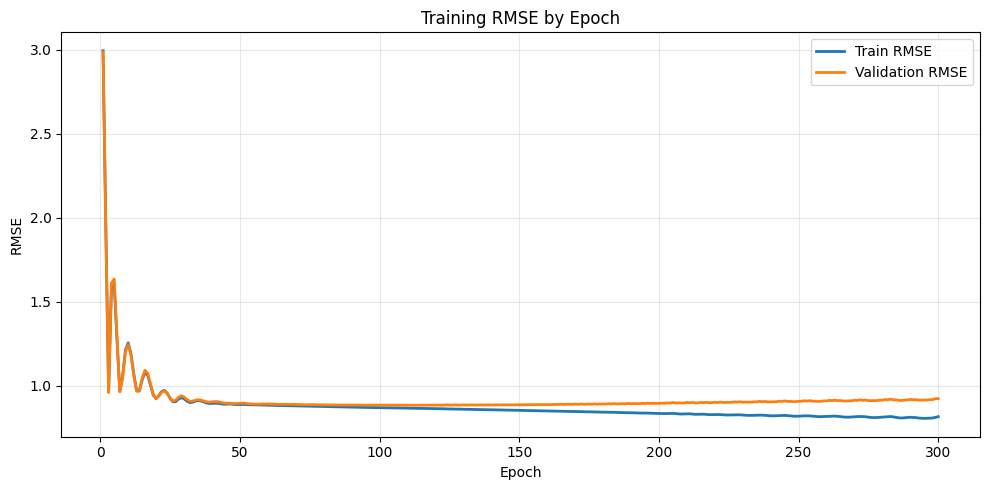

In [102]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    training_history_df["epoch"],
    training_history_df["train_rmse"],
    label="Train RMSE",
    linewidth=2,
)
ax.plot(
    training_history_df["epoch"],
    training_history_df["val_rmse"],
    label="Validation RMSE",
    linewidth=2,
)
ax.set_title("Training RMSE by Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("RMSE")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Movie recommendations

We can now use the model to generate ratings for a movie we haven't seen.


### Load Latest W&B Checkpoint

Download the newest model artifact from W&B, rebuild the regression model, and replace the in-memory model before generating recommendations.


In [103]:
from pathlib import Path
import os

from dotenv import load_dotenv
import torch
import wandb

load_dotenv("../.env")

artifact_name = "movie-rec-link-regression-weights"
artifact_alias = "latest"
wandb_entity = os.getenv("WANDB_ENTITY")
wandb_project = os.getenv("WANDB_PROJECT")

if not wandb_entity or not wandb_project:
    raise ValueError(
        "WANDB_ENTITY and WANDB_PROJECT must be set before loading artifacts."
    )

artifact_path = (
    f"{'/'.join([wandb_entity, wandb_project, artifact_name])}:{artifact_alias}"
)

api = wandb.Api()
artifact = api.artifact(artifact_path, type="model")

download_dir_name = "_".join([artifact_name, artifact.version])
download_dir = Path("artifacts") / download_dir_name
download_dir.mkdir(parents=True, exist_ok=True)

artifact_dir = Path(artifact.download(root=download_dir.as_posix()))
ckpt = torch.load(artifact_dir / "model_best.pt", map_location=device)

loaded_model = Model(hidden_channels=ckpt["config"]["hidden_channels"]).to(device)
warmup_data = train_data.to(device)

with torch.no_grad():
    loaded_model(
        warmup_data.x_dict,
        warmup_data.edge_index_dict,
        warmup_data.edge_attr_dict,
        warmup_data["user", "rates", "movie"].edge_label_index,
    )

loaded_model.load_state_dict(ckpt["model_state_dict"])
loaded_model.eval()
model = loaded_model

print(f"Downloaded artifact: {artifact_path}")
print(f"Local artifact dir: {artifact_dir}")
print(f"Checkpoint epoch: {ckpt.get('epoch', 'n/a')}")
print(f"Checkpoint val_rmse: {ckpt.get('val_rmse', 'n/a')}")

wandb:   3 of 3 files downloaded.  


Downloaded artifact: pedro-stark-ai/movie-rec-pyg/movie-rec-link-regression-weights:latest
Local artifact dir: artifacts\movie-rec-link-regression-weights_v11
Checkpoint epoch: 112
Checkpoint val_rmse: 0.8834715485572815


### Evaluation

From the validation results, our model can generalize well to unseen data. The val RMSE is should be around 0.9, meaning that, on average our model is off by 0.9 stars. We can now evaluate our model on the test set and take a closer look into the predictions.


In [104]:
with torch.no_grad():
    test_data = test_data.to(device)
    pred = model(
        test_data.x_dict,
        test_data.edge_index_dict,
        test_data.edge_attr_dict,
        test_data["user", "rates", "movie"].edge_label_index,
    )
    pred = pred.clamp(min=0, max=5)
    target = test_data["user", "rates", "movie"].edge_label.float()
    rmse = F.mse_loss(pred, target).sqrt()
    print(f"Test RMSE: {rmse:.4f}")

userId = test_data["user", "rates", "movie"].edge_label_index[0].cpu().numpy()
movieId = test_data["user", "rates", "movie"].edge_label_index[1].cpu().numpy()
pred = pred.cpu().numpy()
target = target.cpu().numpy()

print(
    pd.DataFrame(
        {"userId": userId, "movieId": movieId, "rating": pred, "target": target}
    )
)

Test RMSE: 0.8519
       userId  movieId    rating  target
0         379      221  3.842220     3.0
1         605     1871  3.660972     3.0
2         168       88  4.379331     4.0
3         287     2934  3.303284     1.0
4         317       73  4.215301     4.0
...       ...      ...       ...     ...
10078     198     3268  3.232604     4.0
10079     224     4061  3.056638     5.0
10080     155     2243  3.562255     4.5
10081     524      620  2.855204     2.5
10082      45        4  4.424841     5.0

[10083 rows x 4 columns]


### Inference


In [105]:
# Build dataframe from inference-only ratings
personal_ratings_df = pd.DataFrame(personal_ratings)

print(
    "Number movies before eliminating the ones not in the trained movie mapping:",
    len(personal_ratings_df),
)
# Keep only movies that exist in the trained movie mapping
personal_ratings_df = personal_ratings_df.merge(
    unique_movie_id[["movieId", "mappedMovieId"]],
    on="movieId",
    how="inner",
)

print(
    "Number movies after eliminating the ones not in the trained movie mapping:",
    len(personal_ratings_df),
)

# Inference-only user id: one past the largest trained mapped user id
mapped_user_id = int(unique_user_id["mappedUserId"].max()) + 1

# Movies already rated by this unseen user
movies_rated = personal_ratings_df.copy()

# movies_df uses movieId as index, so compare against the index
rated_movie_ids = set(movies_rated["movieId"].tolist())

# Candidate movies = all movies not rated by the unseen user
movies_not_rated = movies_df.loc[~movies_df.index.isin(rated_movie_ids)].copy()

# Bring movieId back as a column so we can merge
movies_not_rated = movies_not_rated.reset_index()

# Attach mappedMovieId
movies_not_rated = movies_not_rated.merge(
    unique_movie_id[["movieId", "mappedMovieId"]],
    on="movieId",
    how="inner",
)

# Sample one unseen movie to score
candidate_movie = movies_not_rated.sample(1, random_state=42)

print(
    f"The movie we want to predict a rating for is: {candidate_movie['title'].iloc[0]}"
)
print(f"Inference-only mapped_user_id: {mapped_user_id}")
print(f"Candidate movieId: {candidate_movie['movieId'].iloc[0]}")
print(f"Candidate mappedMovieId: {candidate_movie['mappedMovieId'].iloc[0]}")

Number movies before eliminating the ones not in the trained movie mapping: 10
Number movies after eliminating the ones not in the trained movie mapping: 10
The movie we want to predict a rating for is: Bernie (1996)
Inference-only mapped_user_id: 610
Candidate movieId: 87413
Candidate mappedMovieId: 8571


In [106]:
import torch
import pandas as pd

model.eval()

# -----------------------------
# 1) Start from the trained graph
# -----------------------------
infer_data = train_data.clone()

# Make sure personal ratings are mapped to existing movie nodes
personal_ratings_df = pd.DataFrame(personal_ratings).merge(
    unique_movie_id[["movieId", "mappedMovieId"]],
    on="movieId",
    how="inner",
)

# New user id = next row in user node feature matrix
new_user_id = infer_data["user"].x.size(0)

# -----------------------------
# 2) Add the new user node
# -----------------------------
feat_dim = infer_data["user"].x.size(1)
new_user_x = torch.ones((1, feat_dim), dtype=infer_data["user"].x.dtype)

infer_data["user"].x = torch.cat([infer_data["user"].x.cpu(), new_user_x], dim=0)

# -----------------------------
# 3) Add edges from new user to rated movies
# -----------------------------
rated_movie_ids = personal_ratings_df["mappedMovieId"].astype(int).tolist()
num_rated = len(rated_movie_ids)

user_to_movie_edges = torch.stack(
    [
        torch.full((num_rated,), new_user_id, dtype=torch.long),
        torch.tensor(rated_movie_ids, dtype=torch.long),
    ]
)

movie_to_user_edges = torch.stack(
    [
        torch.tensor(rated_movie_ids, dtype=torch.long),
        torch.full((num_rated,), new_user_id, dtype=torch.long),
    ]
)

infer_data["user", "rates", "movie"].edge_index = torch.cat(
    [
        infer_data["user", "rates", "movie"].edge_index.cpu(),
        user_to_movie_edges,
    ],
    dim=1,
)

infer_data["user", "rates", "movie"].edge_attr = torch.cat(
    [
        infer_data["user", "rates", "movie"].edge_attr.cpu(),
        torch.tensor(
            personal_ratings_df["rating"].tolist(),
            dtype=infer_data["user", "rates", "movie"].edge_attr.dtype,
        ).unsqueeze(1),
    ],
    dim=0,
)


infer_data["movie", "rev_rates", "user"].edge_index = torch.cat(
    [
        infer_data["movie", "rev_rates", "user"].edge_index.cpu(),
        movie_to_user_edges,
    ],
    dim=1,
)

infer_data["movie", "rev_rates", "user"].edge_attr = torch.cat(
    [
        infer_data["movie", "rev_rates", "user"].edge_attr.cpu(),
        torch.tensor(
            personal_ratings_df["rating"].tolist(),
            dtype=infer_data["movie", "rev_rates", "user"].edge_attr.dtype,
        ).unsqueeze(1),
    ],
    dim=0,
)

# -----------------------------
# 4) Build candidate set: movies not already rated by this unseen user
# -----------------------------
rated_movie_ids_raw = set(personal_ratings_df["movieId"].tolist())

if "movieId" in movies_df.columns:
    candidate_movies = movies_df.loc[
        ~movies_df["movieId"].isin(rated_movie_ids_raw)
    ].copy()
else:
    candidate_movies = (
        movies_df.loc[~movies_df.index.isin(rated_movie_ids_raw)].copy().reset_index()
    )

candidate_movies = candidate_movies.merge(
    unique_movie_id[["movieId", "mappedMovieId"]],
    on="movieId",
    how="inner",
)

# -----------------------------
# 5) Move augmented graph to device
# -----------------------------
infer_data = infer_data.to(device)

In [107]:
model.eval()

candidate_movie_ids = torch.tensor(
    candidate_movies["mappedMovieId"].values,
    dtype=torch.long,
    device=device,
)

candidate_user_ids = torch.full(
    (candidate_movie_ids.size(0),),
    new_user_id,
    dtype=torch.long,
    device=device,
)

edge_label_index = torch.stack(
    [candidate_user_ids, candidate_movie_ids],
    dim=0,
)

with torch.inference_mode():
    pred = model(
        infer_data.x_dict,
        infer_data.edge_index_dict,
        infer_data.edge_attr_dict,
        edge_label_index,
    )

    pred = pred.clamp(0, 5).detach().cpu().numpy()

recommendations_df = candidate_movies[["movieId", "title"]].copy()
recommendations_df["predicted_rating"] = pred

recommendations_df = recommendations_df.sort_values(
    "predicted_rating",
    ascending=False,
)

display(recommendations_df.head(10))

,movieId,title,predicted_rating
7676,89904,The Artist (2011),4.530151
1523,2068,Fanny and Alexander (Fanny och Alexander) (1982),4.413076
1693,2290,Stardust Memories (1980),4.364141
939,1250,"Bridge on the River Kwai, The (1957)",4.354715
961,1272,Patton (1970),4.297626
7562,86345,Louis C.K.: Hilarious (2010),4.272195
8933,136850,Villain (1971),4.258388
6024,40491,"Match Factory Girl, The (Tulitikkutehtaan tytt...",4.208340
951,1262,"Great Escape, The (1963)",4.176350
1720,2324,Life Is Beautiful (La Vita è bella) (1997),4.164816


In [108]:
display(recommendations_df.tail(10))

,movieId,title,predicted_rating
7480,83601,Amer (2009),1.986383
493,580,Princess Caraboo (1994),1.968506
4205,6140,Tenebre (1982),1.951018
9694,189547,Iron Soldier (2010),1.943562
3166,4289,"City of Women, The (Città delle donne, La) (1980)",1.921467
4862,7312,"Follow Me, Boys! (1966)",1.913863
4682,7016,Over the Top (1987),1.911005
9093,145951,Bloodsport: The Dark Kumite (1999),1.902758
7302,77798,"Nightmare on Elm Street, A (2010)",1.898453
5771,31692,Uncle Nino (2003),1.861260


### Analysis of user predictions vs average movie ratings


In [109]:
movie_average_ratings_df = ratings_df.groupby("movieId", as_index=False).agg(
    average_movie_rating=("rating", "mean"),
    rating_count=("rating", "size"),
)

recommendations_comparison_df = recommendations_df.merge(
    movie_average_ratings_df, on="movieId", how="left"
).assign(
    predicted_minus_average=lambda df: (
        df["predicted_rating"] - df["average_movie_rating"]
    ),
    absolute_gap=lambda df: (df["predicted_rating"] - df["average_movie_rating"]).abs(),
)

minimum_rating_count = 5

comparison_summary = recommendations_comparison_df.loc[
    recommendations_comparison_df["average_movie_rating"].notna()
    & (recommendations_comparison_df["rating_count"] > minimum_rating_count)
].copy()

display(
    comparison_summary[
        [
            "movieId",
            "title",
            "predicted_rating",
            "average_movie_rating",
            "predicted_minus_average",
            "rating_count",
        ]
    ].head(15)
)

print(f"Compared movies with more than {minimum_rating_count} ratings.")
print(f"Movies retained: {len(comparison_summary)}")
print(
    f"Correlation between predicted and average ratings: "
    f"{comparison_summary['predicted_rating'].corr(comparison_summary['average_movie_rating']):.3f}"
)
print(f"Mean absolute gap: {comparison_summary['absolute_gap'].mean():.3f}")

,movieId,title,predicted_rating,average_movie_rating,predicted_minus_average,rating_count
0,89904,The Artist (2011),4.530151,4.045455,0.484696,11
3,1250,"Bridge on the River Kwai, The (1957)",4.354715,4.122222,0.232493,45
4,1272,Patton (1970),4.297626,4.121212,0.176414,33
5,86345,Louis C.K.: Hilarious (2010),4.272195,4.055556,0.216639,9
8,1262,"Great Escape, The (1963)",4.176350,4.127907,0.048443,43
9,2324,Life Is Beautiful (La Vita è bella) (1997),4.164816,4.147727,0.017089,88
10,1207,To Kill a Mockingbird (1962),4.151605,4.120690,0.030915,58
12,1203,12 Angry Men (1957),4.135731,4.149123,-0.013392,57
13,3200,"Last Detail, The (1973)",4.101424,4.250000,-0.148576,8
18,86377,Louis C.K.: Shameless (2007),4.074316,4.000000,0.074316,7


Compared movies with more than 5 ratings.
Movies retained: 3258
Correlation between predicted and average ratings: 0.889
Mean absolute gap: 0.247


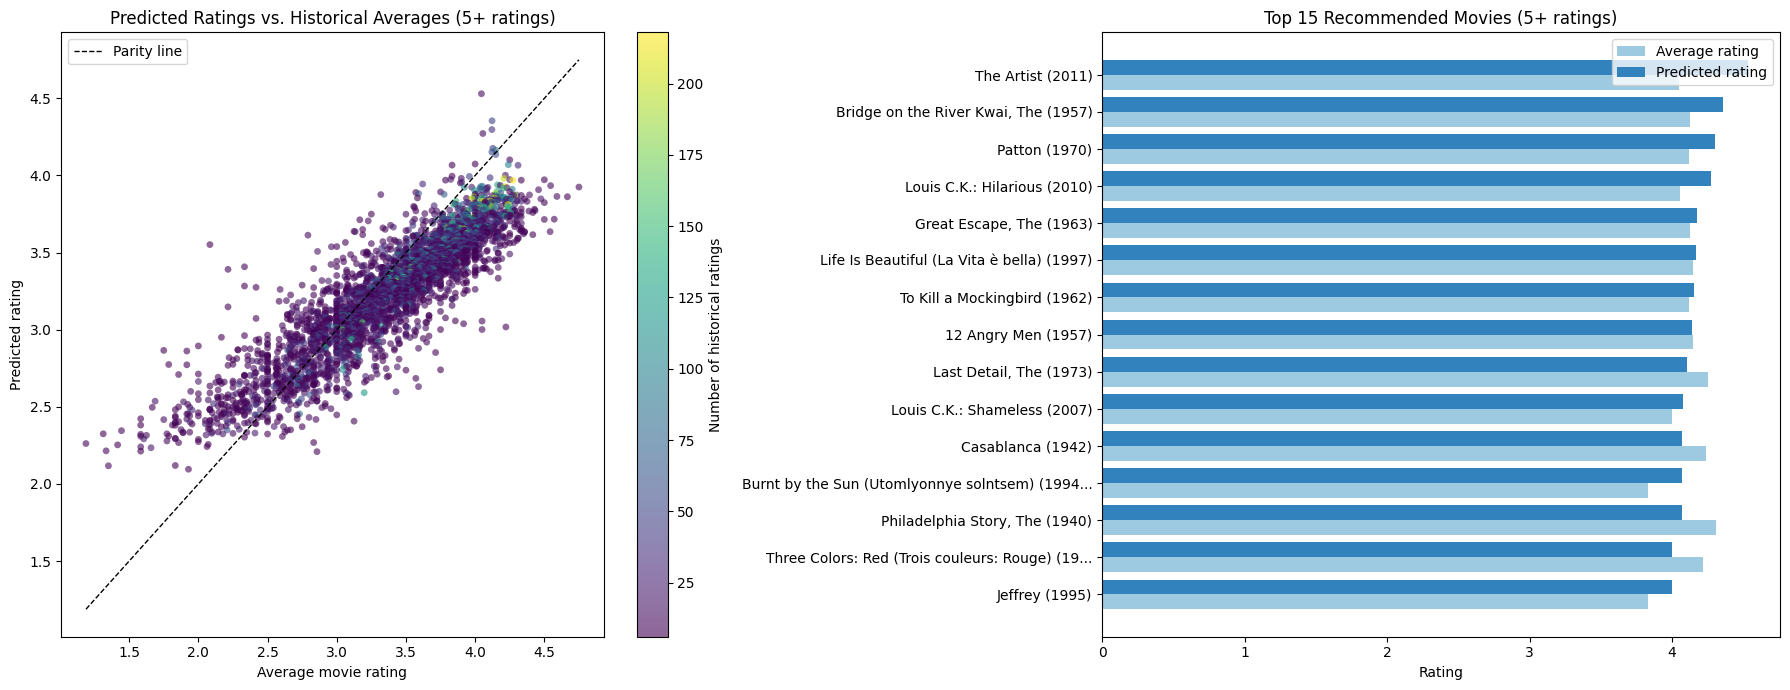

In [110]:
plot_df = comparison_summary.dropna(
    subset=["average_movie_rating", "predicted_rating"]
).copy()

top_plot_df = (
    plot_df.sort_values("predicted_rating", ascending=False)
    .head(15)
    .sort_values("predicted_rating")
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

min_rating = min(
    plot_df["average_movie_rating"].min(),
    plot_df["predicted_rating"].min(),
)
max_rating = max(
    plot_df["average_movie_rating"].max(),
    plot_df["predicted_rating"].max(),
)

scatter = axes[0].scatter(
    plot_df["average_movie_rating"],
    plot_df["predicted_rating"],
    c=plot_df["rating_count"],
    cmap="viridis",
    alpha=0.6,
    s=24,
    edgecolors="none",
)
axes[0].plot(
    [min_rating, max_rating],
    [min_rating, max_rating],
    linestyle="--",
    color="black",
    linewidth=1,
    label="Parity line",
)
axes[0].set_title(
    f"Predicted Ratings vs. Historical Averages ({minimum_rating_count}+ ratings)"
)
axes[0].set_xlabel("Average movie rating")
axes[0].set_ylabel("Predicted rating")
axes[0].legend()
fig.colorbar(scatter, ax=axes[0], label="Number of historical ratings")

y_pos = range(len(top_plot_df))
titles = [
    title[:45] + "..." if len(title) > 45 else title for title in top_plot_df["title"]
]
axes[1].barh(
    [pos - 0.2 for pos in y_pos],
    top_plot_df["average_movie_rating"],
    height=0.4,
    label="Average rating",
    color="#9ecae1",
)
axes[1].barh(
    [pos + 0.2 for pos in y_pos],
    top_plot_df["predicted_rating"],
    height=0.4,
    label="Predicted rating",
    color="#3182bd",
)
axes[1].set_yticks(list(y_pos))
axes[1].set_yticklabels(titles)
axes[1].set_xlabel("Rating")
axes[1].set_title(f"Top 15 Recommended Movies ({minimum_rating_count}+ ratings)")
axes[1].legend()

plt.tight_layout()
plt.show()

,movieId,title,rating,average_movie_rating,user_minus_average,rating_count
0,356,Forrest Gump (1994),5.0,4.164134,0.835866,329
4,2571,"Matrix, The (1999)",5.0,4.192446,0.807554,278
2,296,Pulp Fiction (1994),5.0,4.197068,0.802932,307
8,589,Terminator 2: Judgment Day (1991),4.0,3.970982,0.029018,224
1,318,"Shawshank Redemption, The (1994)",4.0,4.429022,-0.429022,317
6,480,Jurassic Park (1993),3.0,3.750000,-0.750000,238
3,593,"Silence of the Lambs, The (1991)",3.0,4.161290,-1.161290,279
9,527,Schindler's List (1993),3.0,4.225000,-1.225000,220
5,260,Star Wars: Episode IV - A New Hope (1977),3.0,4.231076,-1.231076,251
7,110,Braveheart (1995),1.0,4.031646,-3.031646,237


Average user-minus-average gap: -0.535
Mean absolute user-minus-average gap: 1.030


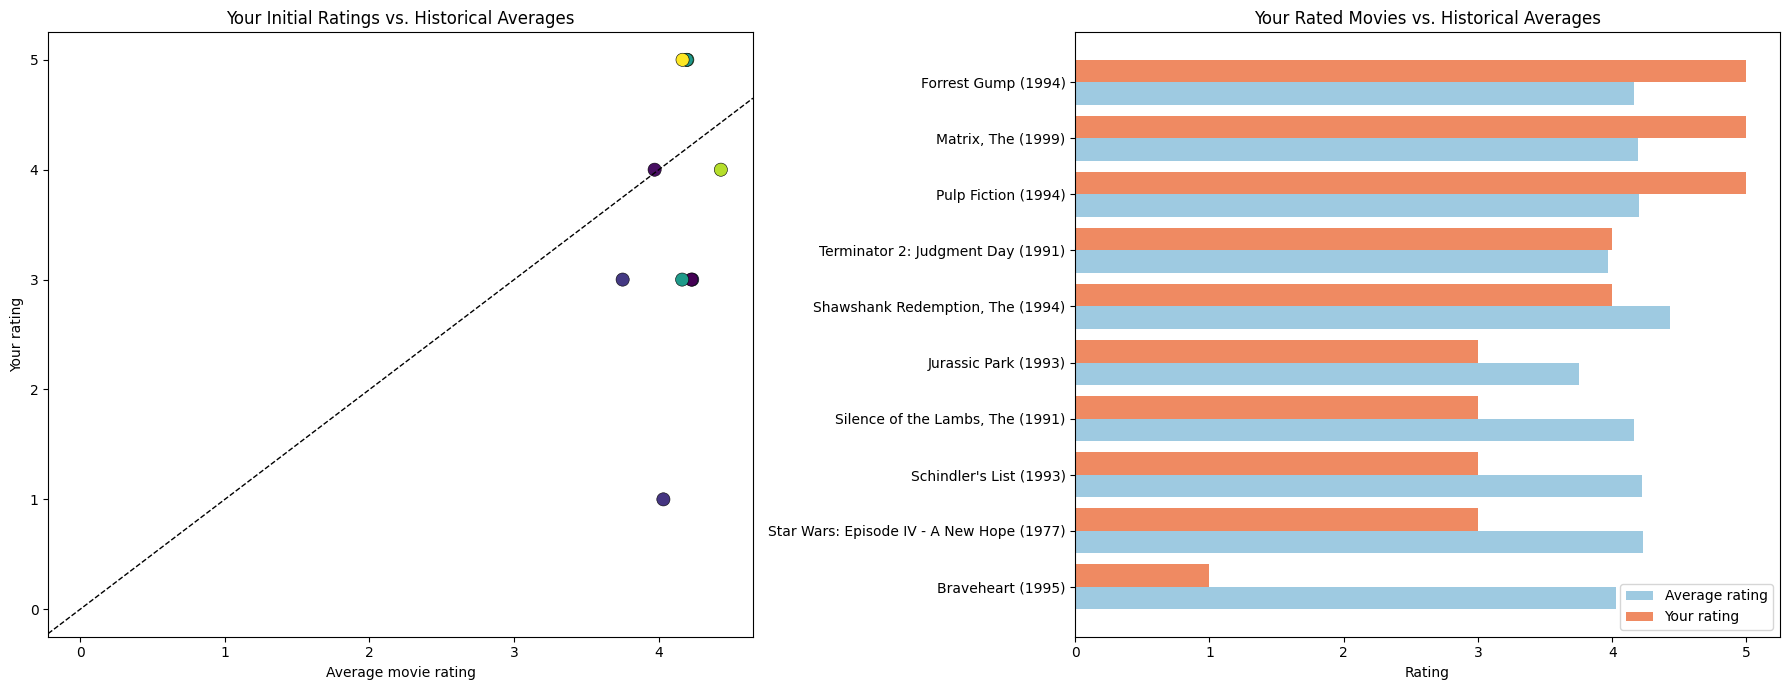

In [111]:
user_baseline_comparison_df = (
    pd.DataFrame(personal_ratings)
    .merge(movie_average_ratings_df, on="movieId", how="left")
    .merge(
        movies_df[["title"]].reset_index(),
        on="movieId",
        how="left",
    )
    .assign(
        user_minus_average=lambda df: df["rating"] - df["average_movie_rating"],
        absolute_gap=lambda df: (df["rating"] - df["average_movie_rating"]).abs(),
    )
    .sort_values("user_minus_average", ascending=False)
)

display(
    user_baseline_comparison_df[
        [
            "movieId",
            "title",
            "rating",
            "average_movie_rating",
            "user_minus_average",
            "rating_count",
        ]
    ]
)

print(
    f"Average user-minus-average gap: "
    f"{user_baseline_comparison_df['user_minus_average'].mean():.3f}"
)
print(
    f"Mean absolute user-minus-average gap: "
    f"{user_baseline_comparison_df['absolute_gap'].mean():.3f}"
)

user_plot_df = user_baseline_comparison_df.sort_values("user_minus_average")
user_y_pos = range(len(user_plot_df))
user_titles = [
    title[:45] + "..." if len(title) > 45 else title for title in user_plot_df["title"]
]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].axline((0, 0), slope=1, linestyle="--", color="black", linewidth=1)
axes[0].scatter(
    user_plot_df["average_movie_rating"],
    user_plot_df["rating"],
    s=90,
    c=user_plot_df["rating_count"],
    cmap="viridis",
    edgecolors="black",
    linewidth=0.4,
)
axes[0].set_title("Your Initial Ratings vs. Historical Averages")
axes[0].set_xlabel("Average movie rating")
axes[0].set_ylabel("Your rating")

axes[1].barh(
    [pos - 0.2 for pos in user_y_pos],
    user_plot_df["average_movie_rating"],
    height=0.4,
    label="Average rating",
    color="#9ecae1",
)
axes[1].barh(
    [pos + 0.2 for pos in user_y_pos],
    user_plot_df["rating"],
    height=0.4,
    label="Your rating",
    color="#ef8a62",
)
axes[1].set_yticks(list(user_y_pos))
axes[1].set_yticklabels(user_titles)
axes[1].set_xlabel("Rating")
axes[1].set_title("Your Rated Movies vs. Historical Averages")
axes[1].legend()

plt.tight_layout()
plt.show()